<a href="https://colab.research.google.com/github/liorzlatin-hub/Deep-Learning-/blob/main/class10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integration + PyTorch + CUDA / Optimization Lab in Colab for Lesson 4”
“What we do: understand how training choices such as learning rate, optimizer, batch size, as well as CUDA/GPU and early stopping, affect the learning process; and connect this to Lesson 4: Finite Differences, Manual Gradients, and Autograd.” In PyTorch, we choose a device and move the data and the model to it.

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    # TODO: print the GPU name
    print("GPU name:", torch.cuda.get_device_name(0))

# TODO: choose cuda if available, otherwise cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#Move tensor to device
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
# TODO: move x to device
x = x.to(device)
print(x)
print("Tensor device:", x.device)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu
tensor([[1., 2.],
        [3., 4.]])
Tensor device: cpu


Small performance test - The benchmark demonstrates the idea only. Sometimes, for small operations, the CPU can be similar in speed or even faster because of overhead.

In [3]:
import time

def matmul_timing(device_name, size=1500):
    dev = torch.device(device_name)
    a = torch.randn(size, size, device=dev)
    b = torch.randn(size, size, device=dev)

    if dev.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    c = a @ b

    if dev.type == "cuda":
        torch.cuda.synchronize()

    return time.time() - start

cpu_time = matmul_timing("cpu")
print("CPU time:", cpu_time)

if torch.cuda.is_available():
    cuda_time = matmul_timing("cuda")
    print("CUDA time:", cuda_time)


CPU time: 0.1723628044128418


We saw several ways to think about optimizing the same model:
1.Enumeration — test many possible values for the parameters.
2.Finite Differences — estimate the gradient by making a small shift in the parameter.
3.Analytical Gradient — manually derive the loss function.
4.Autograd — let PyTorch compute the derivatives automatically.

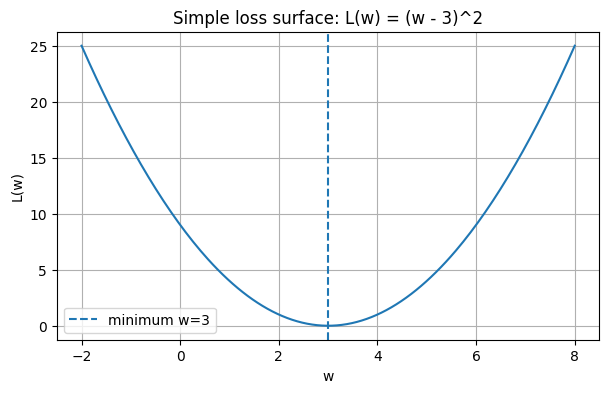

In [4]:
#Loss function with one parameter

import numpy as np
import matplotlib.pyplot as plt

def simple_loss(w):
    return (w - 3) ** 2

w_values = np.linspace(-2, 8, 200)

# TODO: compute the loss for each value of w
loss_values = simple_loss(w_values)

plt.figure(figsize=(7, 4))
plt.plot(w_values, loss_values)
plt.axvline(3, linestyle="--", label="minimum w=3")
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Simple loss surface: L(w) = (w - 3)^2")
plt.legend()
plt.grid(True)
plt.show()

In Enumeration, we do not compute gradients.

We check many possible values of (w), compute the loss for each one, and choose the value with the lowest loss.

Discussion question:
If we have one parameter, this is possible. What happens if we have a million parameters?

In [6]:
candidate_ws = np.linspace(-2, 8, 21)

# compute the loss for every candidate w
candidate_losses = simple_loss(candidate_ws)

# find the index of the best candidate
best_index = np.argmin(candidate_losses)

best_w = candidate_ws[best_index]
best_loss = candidate_losses[best_index]

print("Best w from enumeration:", best_w)
print("Best loss:", best_loss)
print("Best index:", best_index)

Best w from enumeration: 3.0
Best loss: 0.0
Best index: 10


## Method 2 — Finite Differences

Here, we estimate the gradient without taking a manual derivative.

The idea:

$$\frac{dL}{dw} \approx \frac{L(w + \epsilon) - L(w - \epsilon)}{2\epsilon}$$

That is, we check how the loss changes if we move ($w$) a little to the right and a little to the left.

In [8]:
w = 0.0

# choose a small epsilon
eps = 0.001

#compute L(w + eps)
loss_plus = simple_loss(w + eps)

#compute L(w - eps)
loss_minus = simple_loss(w - eps)

#compute the numerical gradient
numerical_grad = (loss_plus - loss_minus) / (2 * eps)

print("w:", w)
print("Numerical gradient:", numerical_grad)

w: 0.0
Numerical gradient: -5.999999999999339


## Method 3 — Analytical Gradient

Here, we compute derivatives manually:

$$L(w) = (w-3)^2$$

And therefore:

$$\frac{dL}{dw} = 2(w-3)$$

In [10]:
def analytical_grad(w):
    # TODO: return the analytical derivative of (w - 3)^2
    return 2 * (w - 3)

w = 0.0
print("Analytical gradient:", analytical_grad(w))

Analytical gradient: -6.0


Method 4 — PyTorch Autograd

In PyTorch, we define the forward computation, and then call:

In [3]:
# TODO: create a tensor w with requires_grad=True
w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

# TODO: compute the loss L(w) = (w - 3)^2
loss = (w - 3) ** 2

# TODO: ask PyTorch to compute gradients
loss.backward()

print("Loss:", loss.item())
print("Autograd gradient:", w.grad.item())

w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
lr = 0.1

for step in range(10):
    # TODO: compute loss
    loss = (w - 3) ** 2

    # TODO: compute gradient using backward
    loss.backward()

    with torch.no_grad():
        # TODO: update w manually using gradient descent
        w -= lr * w.grad

    # TODO: zero the gradient before the next step
    w.grad.zero_()

    print(f"step={step:02d} | w={w.item():.4f} | loss={loss.item():.4f}")

Loss: 9.0
Autograd gradient: -6.0
step=00 | w=0.6000 | loss=9.0000
step=01 | w=1.0800 | loss=5.7600
step=02 | w=1.4640 | loss=3.6864
step=03 | w=1.7712 | loss=2.3593
step=04 | w=2.0170 | loss=1.5099
step=05 | w=2.2136 | loss=0.9664
step=06 | w=2.3709 | loss=0.6185
step=07 | w=2.4967 | loss=0.3958
step=08 | w=2.5973 | loss=0.2533
step=09 | w=2.6779 | loss=0.1621


Create dataset for bibnry classification Create synthetic data so we can focus on training rather than collecting data.
Goal: classify each example into class 0 or class 1.

> Add blockquote



In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

# TODO: print shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 10)
y shape: (1500,)


Use train for parameters updating and validation during preactice.


In [7]:
# TODO: split the data to train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])

Train size: 1200
Validation size: 300


Standardization

We will normalize the features so that all features are on a similar scale.

In [ ]:
scaler = StandardScaler()

# fit on train and transform train
X_train = scaler.fit_transform(X_train)

# TODO: transform validation using the same scaler
X_val = scaler.transform(X_val)

Pytorch Tensors Variation

In [ ]:
# TODO: convert arrays to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# TODO: move all tensors to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

print(X_train.shape, y_train.shape)
print("X_train device:", X_train.device)

In [ ]:
Basix model - The model takes 10 features and outputs one logit for binary classification.

In [ ]:
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(10, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


Part 4 — Training Function for Experiments

We will write a general function so that each time we can change only one parameter: optimizer, learning rate, or batch size.

In [25]:
def train_experiment(
    optimizer_name="SGD",
    lr=0.01,
    batch_size=32,
    epochs=50
):
    torch.manual_seed(42)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = SmallClassifier().to(device)

    # TODO: choose the correct loss for binary classification with logits
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'SGD' or 'Adam'")

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            # TODO: forward pass
            logits = model(xb)

            # TODO: compute loss
            loss = criterion(logits, yb)

            # TODO: zero gradients, backward, optimizer step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return model, train_losses, val_losses




### Run an Experiment and Plot Results

Let's run our first training experiment with the default settings (SGD optimizer, learning rate 0.01, batch size 32, 50 epochs) and visualize the loss curves.

Using device for training: cpu


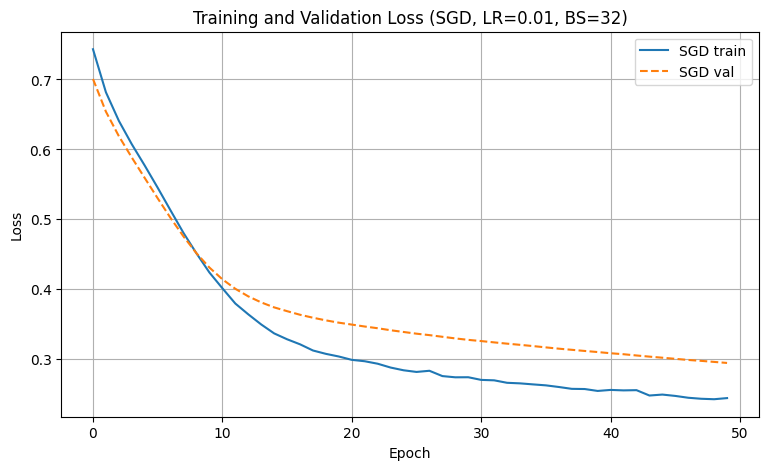

In [32]:
import torch
import numpy as np # Ensure numpy is imported for np.mean in train_experiment
import torch.nn as nn # Ensure nn is imported for SmallClassifier

# Define device here as it might not have been run in previous cells
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for training: {device}")

# SmallClassifier class definition (copied from USEDh15jHimV) to ensure it's in scope
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(10, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


if not isinstance(X_train, torch.Tensor):
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
if not isinstance(y_train, torch.Tensor):
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
if not isinstance(X_val, torch.Tensor):
    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
if not isinstance(y_val, torch.Tensor):
    y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

model_sgd, train_losses_sgd, val_losses_sgd = train_experiment(
    optimizer_name="SGD",
    lr=0.01,
    batch_size=32,
    epochs=50
)

results = [
    ("SGD", train_losses_sgd, val_losses_sgd)
]

plot_losses(results, "Training and Validation Loss (SGD, LR=0.01, BS=32)")

In [33]:
def plot_losses(results, title):
    plt.figure(figsize=(9, 5))

    for label, train_losses, val_losses in results:
        plt.plot(train_losses, label=f"{label} train")
        plt.plot(val_losses, linestyle="--", label=f"{label} val")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

Basic Practice on model.

In [29]:
model, train_losses, val_losses = train_experiment(
    optimizer_name="Adam",
    lr=0.01,
    batch_size=32,
    epochs=50
)

plot_losses(
    [("Adam lr=0.01 batch=32", train_losses, val_losses)],
    "Basic Training Run"
)

TypeError: 'int' object is not callable

For stock prediction, which often involves complex models like neural networks (e.g., LSTMs, Transformers, etc.) and large datasets, Method 4 — PyTorch Autograd is by far the best choice. Here's why: Complex Models: Stock prediction models can have millions of parameters. Manually deriving gradients (Analytical Gradient) for such models is practically impossible and extremely error-prone.
Efficiency: Both Enumeration and Finite Differences are computationally very expensive. Enumeration becomes infeasible with even a moderate number of parameters, and Finite Differences requires multiple forward passes per

Mini-update: Manual Gradient Descent

Now we will see a few steps of Gradient Descent using the gradient computed by Autograd.

We will use the rule:

w
←
w
−
l
r
⋅
d
L
d
w
w←w−lr⋅
dw
dL
​


In [19]:
import torch

w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
lr = 0.1

for step in range(10):
    # compute loss
    loss = (w - 3) ** 2

    # compute gradient using backward
    loss.backward()

    with torch.no_grad():
        # update w manually using gradient descent
        w -= lr * w.grad

    # zero the gradient before the next step
    w.grad.zero_()

    print(f"step={step:02d} | w={w.item():.4f} | loss={loss.item():.4f}")

step=00 | w=0.6000 | loss=9.0000
step=01 | w=1.0800 | loss=5.7600
step=02 | w=1.4640 | loss=3.6864
step=03 | w=1.7712 | loss=2.3593
step=04 | w=2.0170 | loss=1.5099
step=05 | w=2.2136 | loss=0.9664
step=06 | w=2.3709 | loss=0.6185
step=07 | w=2.4967 | loss=0.3958
step=08 | w=2.5973 | loss=0.2533
step=09 | w=2.6779 | loss=0.1621


Part 2 — Creating a Dataset for Binary Classification

We will create synthetic data so we can focus on training rather than data collection.
Goal: classify each example into class 0 or class 1.

Part 2 — Creating a Dataset for Binary Classification

We will create synthetic data so we can focus on training rather than data collection.
Goal: classify each example into class 0 or class 1.


In [37]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

# TODO: print shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 10)
y shape: (1500,)


Train / Validation

We will use the train set to update the parameters, and the validation set for evaluation during training.

In [38]:
# TODO: split the data to train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])

Train size: 1200
Validation size: 300


Standardization

We will normalize the features so that all features are on a similar scale.

In [44]:
scaler = StandardScaler()

# fit on train and transform train
X_train = scaler.fit_transform(X_train)

# transform validation using the same scaler
X_val = scaler.transform(X_val)

### Feature Scaling and DataLoader Creation

We'll standardize the features using `StandardScaler` and then convert our data into PyTorch `TensorDataset` and `DataLoader` objects. This prepares the data for efficient training in batches.

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Imports for data generation, splitting, and scaling
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np # For random seed

# Re-generate synthetic data (copied from xXdkGhU_wylH)
np.random.seed(42)
# torch.manual_seed(42) # Already in xXdkGhU_wylH

X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

# Re-split the data to train and validation (copied from 41FscNWGxRo1)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Re-scale the features (copied from 8wK1WBOMx_9M)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Add a dimension for binary classification
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"First batch from train_loader (X.shape, y.shape):")
for X_batch, y_batch in train_loader:
    print(X_batch.shape, y_batch.shape)
    break

X_train_tensor shape: torch.Size([1200, 10])
y_train_tensor shape: torch.Size([1200, 1])
First batch from train_loader (X.shape, y.shape):
torch.Size([64, 10]) torch.Size([64, 1])


### Visualize the Synthetic Data (Optional)

Let's visualize the first two features of our synthetic dataset to get a sense of its separability.

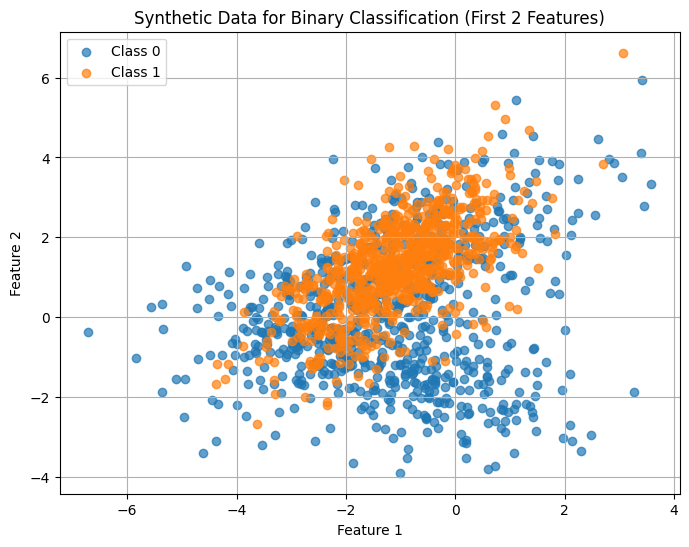

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', alpha=0.7)
plt.title('Synthetic Data for Binary Classification (First 2 Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 4. Define the Binary Classification Model

We'll create a simple feedforward neural network for binary classification. It will consist of a few linear layers with ReLU activation and a final sigmoid output layer.

In [41]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size):
        super(BinaryClassifier, self).__init__()
        self.layer_1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.sigmoid(self.layer_3(x))
        return x

# Initialize the model
input_size = X_train_tensor.shape[1] # Number of features
model = BinaryClassifier(input_size)

# Define Loss function and Optimizer
criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

BinaryClassifier(
  (layer_1): Linear(in_features=10, out_features=64, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=64, out_features=32, bias=True)
  (layer_3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 5. Train the Model

We will now train our binary classification model using the training data and evaluate its performance on the validation set after each epoch.

In [42]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Epoch [{epoch+1}/{num_epochs}], ' \
          f'Train Loss: {running_loss/len(train_loader):.4f}, ' \
          f'Validation Loss: {val_loss/len(val_loader):.4f}, ' \
          f'Validation Accuracy: {100 * correct / total:.2f}%')

Epoch [1/50], Train Loss: 0.6472, Validation Loss: 0.6018, Validation Accuracy: 85.00%
Epoch [2/50], Train Loss: 0.5425, Validation Loss: 0.4956, Validation Accuracy: 84.67%
Epoch [3/50], Train Loss: 0.4217, Validation Loss: 0.4009, Validation Accuracy: 85.33%
Epoch [4/50], Train Loss: 0.3257, Validation Loss: 0.3399, Validation Accuracy: 85.33%
Epoch [5/50], Train Loss: 0.2662, Validation Loss: 0.3066, Validation Accuracy: 87.33%
Epoch [6/50], Train Loss: 0.2369, Validation Loss: 0.2825, Validation Accuracy: 88.67%
Epoch [7/50], Train Loss: 0.2146, Validation Loss: 0.2639, Validation Accuracy: 90.00%
Epoch [8/50], Train Loss: 0.2002, Validation Loss: 0.2518, Validation Accuracy: 90.00%
Epoch [9/50], Train Loss: 0.1867, Validation Loss: 0.2402, Validation Accuracy: 91.67%
Epoch [10/50], Train Loss: 0.1790, Validation Loss: 0.2333, Validation Accuracy: 92.33%
Epoch [11/50], Train Loss: 0.1679, Validation Loss: 0.2268, Validation Accuracy: 92.67%
Epoch [12/50], Train Loss: 0.1610, Valida

### 6. Evaluate the Final Model

Let's get the final accuracy on the validation set.

In [43]:
model.eval() # Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = 100 * correct / total
print(f'Final Validation Accuracy of the model on the {total} test samples: {final_accuracy:.2f}%')

Final Validation Accuracy of the model on the 300 test samples: 93.33%


## Stock Prediction: Naive Baseline + LSTM

This section will implement a stock prediction model that forecasts the next day's closing price using historical data. We will compare a simple Naive Baseline with a more sophisticated Long Short-Term Memory (LSTM) neural network.

### 1. Data Acquisition and Preprocessing

We'll use `yfinance` to download historical stock data and `scikit-learn` for data scaling, which is crucial for neural networks like LSTMs. We will focus on the 'Close' price for prediction.

In [20]:
# Install necessary libraries
!pip install yfinance scikit-learn matplotlib

import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Learning rate experiment

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
results = []

for lr in learning_rates:
    model, train_losses, val_losses = train_experiment(
        optimizer_name="SGD",
        lr=lr,
        batch_size=32,
        epochs=50
    )
    results.append((f"lr={lr}", train_losses, val_losses))

plot_losses(results, "Effect of Learning Rate with SGD")


ADAM VS GSD

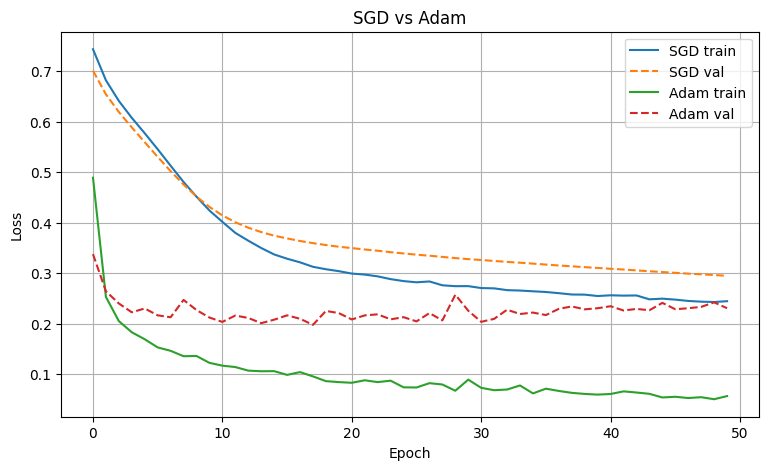

In [34]:
results = []

for optimizer_name in ["SGD", "Adam"]:
    model, train_losses, val_losses = train_experiment(
        optimizer_name=optimizer_name,
        lr=0.01,
        batch_size=32,
        epochs=50
    )
    results.append((optimizer_name, train_losses, val_losses))

plot_losses(results, "SGD vs Adam")


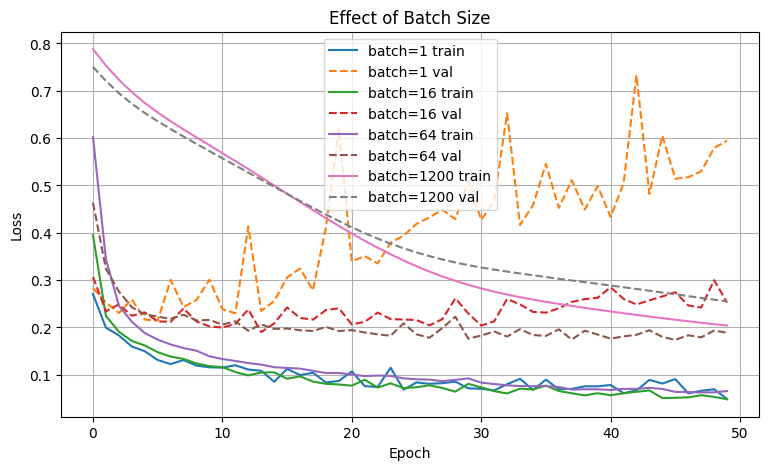

In [35]:
batch_sizes = [1, 16, 64, len(X_train)]
results = []

for batch_size in batch_sizes:
    model, train_losses, val_losses = train_experiment(
        optimizer_name="Adam",
        lr=0.01,
        batch_size=batch_size,
        epochs=50
    )
    results.append((f"batch={batch_size}", train_losses, val_losses))

plot_losses(results, "Effect of Batch Size")


The influence of batch size

Part 9 — Early Stopping | Validation

We will check when it is worth stopping training based on the validation loss.

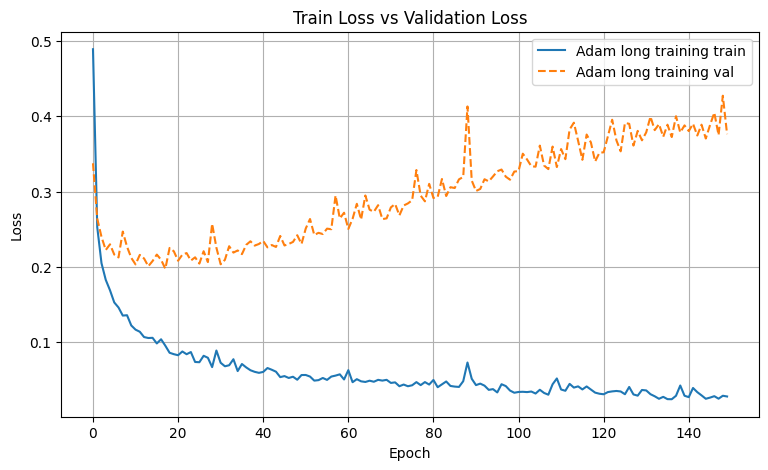

In [38]:
model, train_losses, val_losses = train_experiment(
    optimizer_name="Adam",
    lr=0.01,
    batch_size=32,
    epochs=150
)

plot_losses(
    [("Adam long training", train_losses, val_losses)],
    "Train Loss vs Validation Loss"
)



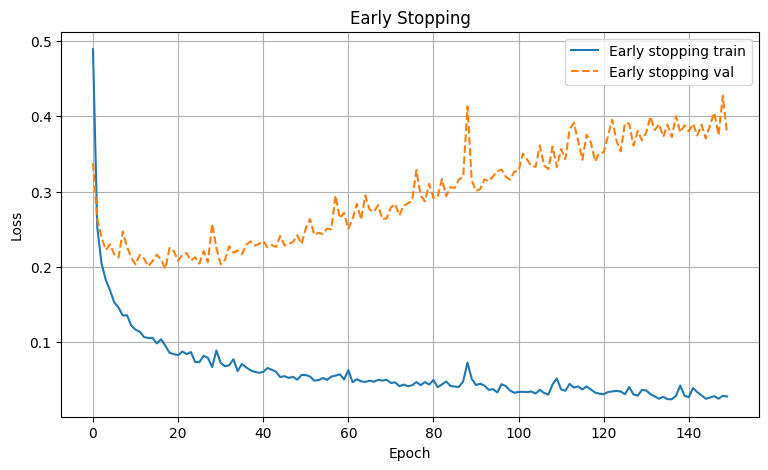

In [39]:
def train_with_early_stopping(
    lr=0.01,
    batch_size=32,
    max_epochs=150,
    patience=10
):
    torch.manual_seed(42)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = SmallClassifier().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # TODO: update best validation loss and patience counter
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        # TODO: stop if patience is reached
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            print(f"Best validation loss: {best_val_loss:.4f}")
            print(f"Best epoch: {best_epoch}")
            break

    return model, train_losses, val_losses

    model, train_losses, val_losses = train_with_early_stopping(
    lr=0.01,
    batch_size=32,
    max_epochs=150,
    patience=10
)

plot_losses(
    [("Early stopping", train_losses, val_losses)],
    "Early Stopping"
)

Accuracy — Part 10

In classification, it is not enough to check the loss. We also calculate accuracy.

In [ ]:
def evaluate_accuracy(model):
    model.eval()

    with torch.no_grad():
        logits = model(X_val)

        # TODO: convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # TODO: convert probabilities to class predictions
        predictions = (probabilities > 0.5).float()

        accuracy = (predictions == y_val).float().mean().item()

    return accuracy

accuracy = evaluate_accuracy(model)
print(f"Validation accuracy: {accuracy:.4f}")

/tmp/ipykernel_7657/1588420615.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


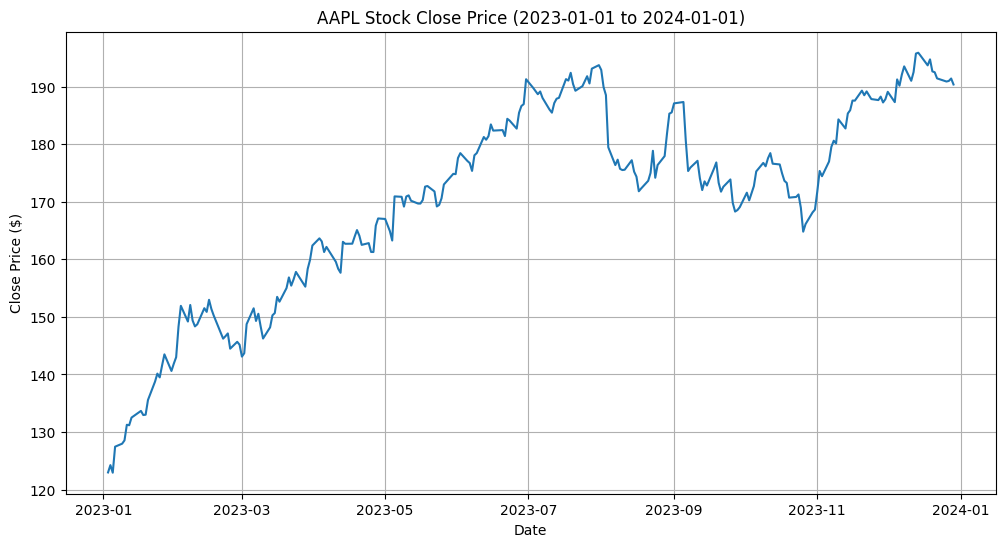

Data head:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.982719  128.715417  122.097738  128.105769  112117500
2023-01-04  124.251183  126.512801  122.992546  124.772336   89113600
2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
2023-01-06  127.456795  128.115611  122.805737  123.907048   87754700
2023-01-09  127.977943  131.183547  127.722288  128.292610   70790800


In [22]:
# Download historical stock data (e.g., Apple stock)
ticker = "AAPL"
start_date = "2023-01-01" # Last year's data
end_date = "2024-01-01"

df = yf.download(ticker, start=start_date, end=end_date)

# Use only the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

plt.figure(figsize=(12, 6))
plt.plot(df.index, data)
plt.title(f'{ticker} Stock Close Price ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.show()

print("Data head:")
print(df.head())

### Data Scaling and Sequence Creation

LSTMs work best with scaled data. We'll scale the 'Close' prices between 0 and 1. Also, LSTMs require sequential input; we'll create sequences where a certain number of past days' prices predict the next day's price.

In [23]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

sequence_length = 10 # Use 10 past days to predict the next day
X, y = create_sequences(scaled_data, sequence_length)

# Split data into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)
X_test_tensor = torch.from_numpy(X_test).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

print(f"X_train shape: {X_train_tensor.shape}")
print(f"y_train shape: {y_train_tensor.shape}")
print(f"X_test shape: {X_test_tensor.shape}")
print(f"y_test shape: {y_test_tensor.shape}")

X_train shape: torch.Size([192, 10, 1])
y_train shape: torch.Size([192, 1])
X_test shape: torch.Size([48, 10, 1])
y_test shape: torch.Size([48, 1])


### 2. Naive Baseline Policy

The simplest prediction is to assume the next day's closing price will be the same as today's closing price. We'll use this as our baseline for comparison.

Naive Baseline RMSE: 1.8359


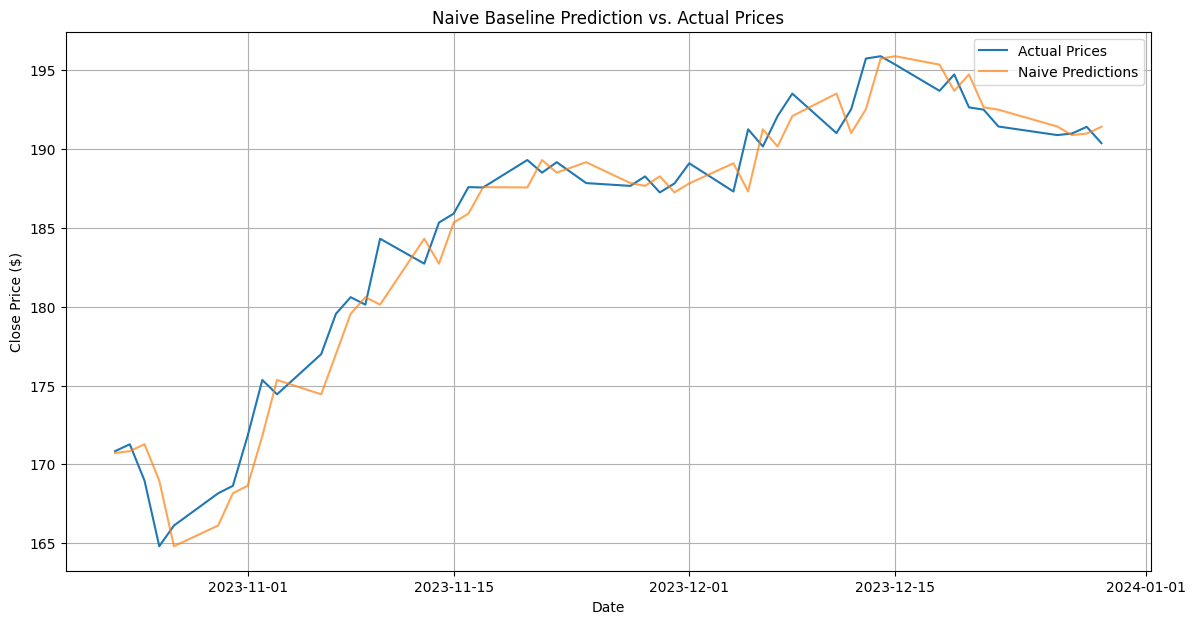

In [25]:
# Naive baseline: predict next day's price is today's price
# For the test set, this means the prediction for day 'i+1' is the actual price of day 'i'

# The actual values for comparison are y_test
n_test_samples = len(y_test)

# Naive predictions will be the last value of each sequence in X_test
# Note: X_test contains sequences, so X_test[:, -1, 0] gives the last day's price of each sequence
# We also need to inverse transform them to compare with original scale
naive_predictions_scaled = X_test_tensor[:, -1, 0].cpu().numpy().reshape(-1, 1)
naive_predictions = scaler.inverse_transform(naive_predictions_scaled)

# The actual values for y_test are also scaled, so we need to inverse transform them
y_test_actual = scaler.inverse_transform(y_test)

# Calculate RMSE for the naive baseline
naive_rmse = np.sqrt(mean_squared_error(y_test_actual, naive_predictions))
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

# Plot Naive Baseline predictions vs. Actual
plt.figure(figsize=(14, 7))
plt.plot(df.index[train_size + sequence_length:], y_test_actual, label='Actual Prices')
plt.plot(df.index[train_size + sequence_length:], naive_predictions, label='Naive Predictions', alpha=0.7)
plt.title('Naive Baseline Prediction vs. Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.show()

### 3. LSTM Model Implementation

Now, we'll define our LSTM model using PyTorch. The model will take a sequence of past stock prices and output a prediction for the next day's price.

In [29]:
# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1, 1, self.hidden_layer_size).to(device),
                            torch.zeros(1, 1, self.hidden_layer_size).to(device))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq), 1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

# Initialize the model, loss function, and optimizer
model = LSTMModel().to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMModel(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


### 4. Training the LSTM Model

We will train the LSTM model using our prepared training data. We'll use the Autograd mechanism in PyTorch to compute gradients and update the model's weights.

In [30]:
# Training the model
epochs = 100

for i in range(epochs):
    for seq, labels in zip(X_train_tensor, y_train_tensor):
        optimizer.zero_grad() # Zero gradients before each epoch
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size).to(device),
                            torch.zeros(1, 1, model.hidden_layer_size).to(device))

        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward() # Compute gradients using Autograd
        optimizer.step() # Update weights

    if i%25 == 0:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

epoch:   0 loss: 0.01173409
epoch:  25 loss: 0.00117543
epoch:  50 loss: 0.00074810
epoch:  75 loss: 0.00043186
epoch:  99 loss: 0.00053845


### 5. Making Predictions and Evaluation

After training, we'll use the model to make predictions on the test set and evaluate its performance using RMSE, comparing it with our Naive Baseline.

LSTM Model RMSE: 7.4166
Naive Baseline RMSE: 1.8359


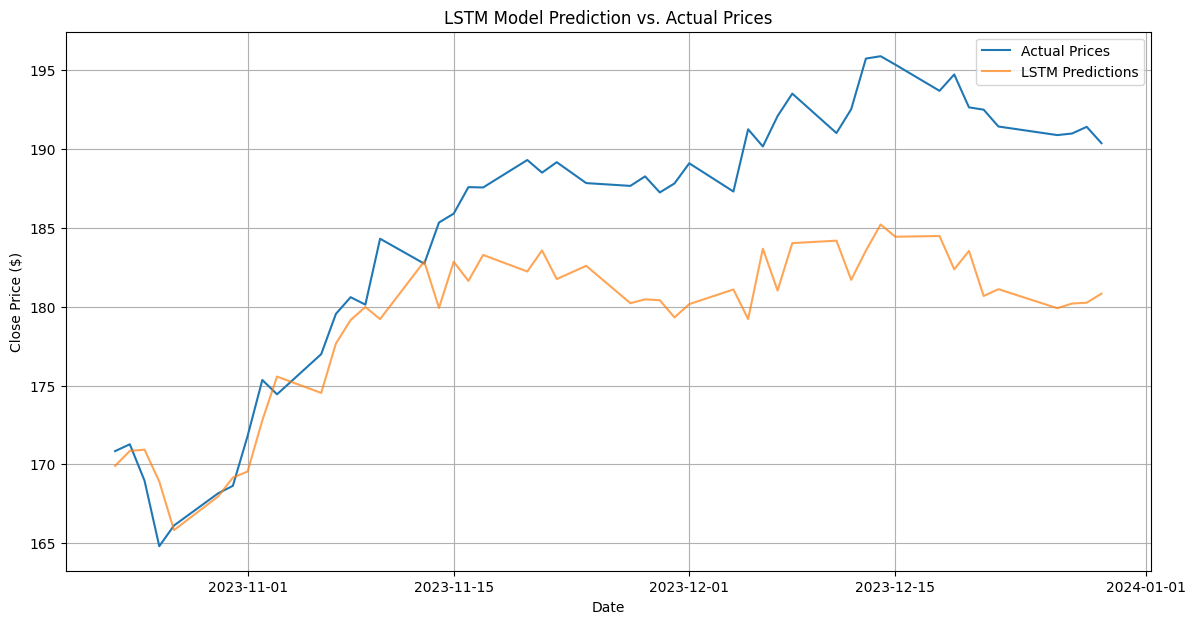

In [31]:
# Make predictions on the test set
model.eval() # Set the model to evaluation mode

test_predictions = []
with torch.no_grad(): # Disable gradient calculation for predictions
    for seq in X_test_tensor:
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size).to(device),
                            torch.zeros(1, 1, model.hidden_layer_size).to(device))
        test_predictions.append(model(seq).item())

# Inverse transform the predictions and actual values to original scale
test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_actual_lstm = scaler.inverse_transform(y_test_tensor.cpu().numpy())

# Calculate RMSE for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual_lstm, test_predictions))
print(f"LSTM Model RMSE: {lstm_rmse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

# Plot LSTM predictions vs. Actual
plt.figure(figsize=(14, 7))
plt.plot(df.index[train_size + sequence_length:], y_test_actual_lstm, label='Actual Prices')
plt.plot(df.index[train_size + sequence_length:], test_predictions, label='LSTM Predictions', alpha=0.7)
plt.title('LSTM Model Prediction vs. Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import torch
import matplotlib.pyplot as plt

w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
lr = 0.1
num_iterations = 10

# Lists to store w and loss values for plotting
w_history = []
loss_history = []

print(f"Initial w: {w.item():.2f}")

for step in range(num_iterations):
    # compute loss
    loss = (w - 3) ** 2

    # Store current values for plotting
    w_history.append(w.item())
    loss_history.append(loss.item())

    # compute gradient using backward
    loss.backward()

    # Print current iteration details AFTER computing grad but BEFORE zeroing or updating w
    print(f"Iteration {step+1}: w = {w.item():.2f}, Loss = {loss.item():.2f}, Grad = {w.grad.item():.2f}")

    with torch.no_grad():
        # update w manually using gradient descent
        w -= lr * w.grad

    # zero the gradient before the next step
    w.grad.zero_()

print(f"\nFinal w after {num_iterations} iterations: {w.item():.2f}")

Initial w: 0.00
Iteration 1: w = 0.00, Loss = 9.00, Grad = -6.00
Iteration 2: w = 0.60, Loss = 5.76, Grad = -4.80
Iteration 3: w = 1.08, Loss = 3.69, Grad = -3.84
Iteration 4: w = 1.46, Loss = 2.36, Grad = -3.07
Iteration 5: w = 1.77, Loss = 1.51, Grad = -2.46
Iteration 6: w = 2.02, Loss = 0.97, Grad = -1.97
Iteration 7: w = 2.21, Loss = 0.62, Grad = -1.57
Iteration 8: w = 2.37, Loss = 0.40, Grad = -1.26
Iteration 9: w = 2.50, Loss = 0.25, Grad = -1.01
Iteration 10: w = 2.60, Loss = 0.16, Grad = -0.81

Final w after 10 iterations: 2.68


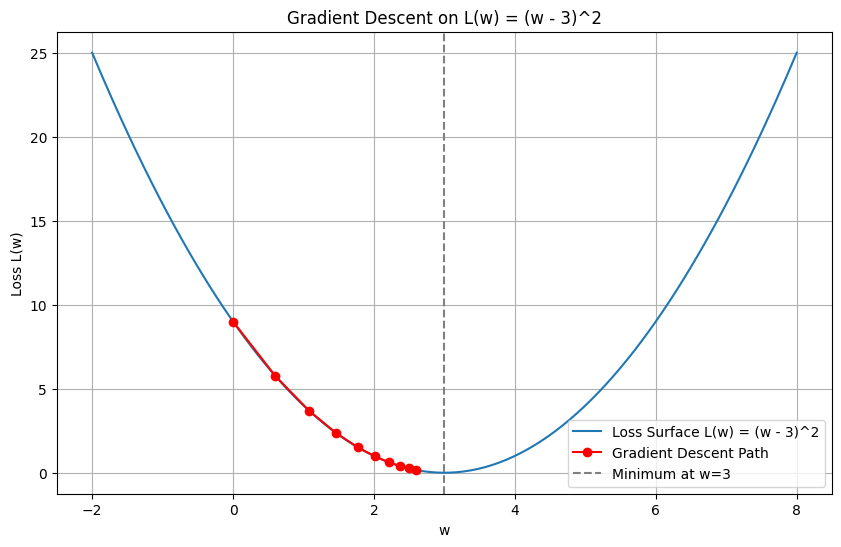

In [15]:
# Plotting the gradient descent path
plt.figure(figsize=(10, 6))
plt.plot(w_values, loss_values, label='Loss Surface L(w) = (w - 3)^2')
plt.plot(w_history, loss_history, 'o-', color='red', label='Gradient Descent Path')
plt.axvline(3, linestyle="--", color='gray', label="Minimum at w=3")
plt.xlabel('w')
plt.ylabel('Loss L(w)')
plt.title('Gradient Descent on L(w) = (w - 3)^2')
plt.legend()
plt.grid(True)
plt.show()